# Du doan Tu vong do Tai nan Giao thong tai Canada
**Pipeline nghien cuu dua tren NCDB (National Collision Database) 1999-2017**

Noi dung notebook:
1. **Thu thap & Mo ta Du lieu** - NCDB Canada, 2.57M vu va cham, 6.77M quan sat
2. **Tien xu ly Du lieu** - Gop nhan muc tieu, xu ly thieu (story-based + MICE), loc
3. **Phan tich Kham pha (EDA)** - Thong ke don bien/hai bien/da bien, Apriori
4. **Xay dung Mo hinh** - Lasso Regression & XGBoost, xu ly mat can bang lop
5. **Danh gia & Ket luan** - Accuracy, Sensitivity, Specificity, Feature Importance


---
## 1. Thu thap & Mo ta Du lieu

**Nguon:** National Collision Database (NCDB) Canada, 1999-2017  
**Quy mo:** ~2.57 trieu vu va cham, ~6.77 trieu quan sat (person-level)  
**Bien so:** 23 cot thuoc 3 nhom - va cham (C_*), phuong tien (V_*), ca nhan (P_*)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import json

import sys
import subprocess, importlib.metadata
try:
    ver = importlib.metadata.version('jupyter_client')
    if tuple(int(v) for v in ver.split('.')[:2]) < (8, 0):
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'jupyter_client'])
        print('Upgraded jupyter_client. Please Restart kernel (Kernel -> Restart) then Run All.')
except Exception:
    pass

warnings.filterwarnings('ignore', message='.*utcnow.*')
warnings.filterwarnings('ignore', message='.*datetime.*deprecated.*')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150

KAGGLE_MODE = os.path.isdir('/kaggle/input')
if KAGGLE_MODE:
    found = []
    for root, dirs, fnames in os.walk('/kaggle/input'):
        for f in fnames:
            if f.endswith(('.csv', '.csv.gz')):
                found.append(os.path.join(root, f))
    DATA_DIR = os.path.dirname(found[0]) if found else '/kaggle/input'
else:
    DATA_DIR = 'data/canada-dataset'
OUT_DIR = 'outputs/canada_pipeline'
os.makedirs(OUT_DIR, exist_ok=True)

NA_CODES = {'UU', 'NN', 'QQ', 'U', 'N', 'Q', 'XX', 'NNNN'}

def clean_numeric(series, dtype=float):
    if series.dtype != 'object':
        return series.astype(dtype)
    s = series.copy()
    s = s.where(~s.isin(NA_CODES), np.nan)
    return pd.to_numeric(s, errors='coerce').astype(dtype)

print('Thu vien da duoc tai.')


In [ ]:
import glob
files = sorted(glob.glob(os.path.join(DATA_DIR, '**/*.csv*'), recursive=True))
print(f'So luong file: {len(files)}')
if files:
    basenames = [os.path.basename(f) for f in files]
    print(f'Pham vi: {basenames[0][:9]} -> {basenames[-1][:9]}')
else:
    raise FileNotFoundError(
        f'Khong tim thay file CSV trong {DATA_DIR}. '
    )

df_list = []
for f in files:
    yr = int(os.path.basename(f)[2:6])
    df = pd.read_csv(f, low_memory=False, dtype=str)
    df_list.append(df)
    print(f'  {os.path.basename(f)}: {len(df):>9,} dong')

data = pd.concat(df_list, ignore_index=True)
print(f'\nTong: {len(data):,} person-level records')
print(f'Columns ({len(data.columns)}): {data.columns.tolist()}')


In [ ]:
n_collisions = data['C_CASE'].nunique()
print(f'So vu va cham: {n_collisions:,}')
print(f'So quan sat: {len(data):,}')


### Mo ta cac bien so

| Nhom | Bien | Mo ta |
|------|------|------|
| **Va cham** | C_YEAR | Nam xay ra |
| | C_MNTH | Thang |
| | C_WDAY | Ngay trong tuan |
| | C_HOUR | Gio |
| | C_SEV | Muc do nghiem trong (1=thuong vong, 2=thiet hai tai san) |
| | C_VEHS | So phuong tien |
| | C_CONF | Cau hinh va cham |
| | C_RCFG | Cau hinh duong |
| | C_WTHR | Thoi tiet |
| | C_RSUR | Be mat duong |
| | C_RALN | Can chinh duong |
| | C_TRAF | Kiem soat giao thong |
| **Phuong tien** | V_TYPE | Loai xe |
| | V_YEAR | Nam san xuat |
| **Ca nhan** | P_SEX | Gioi tinh |
| | P_AGE | Tuoi |
| | P_PSN | Vi tri ngoi |
| | P_ISEV | Muc do thuong tich |
| | P_SAFE | Thiet bi an toan |
| | P_USER | Loai nguoi tham gia giao thong |


---
## 2. Tien xu ly Du lieu


### 2.1. Lam sach du lieu
Du lieu NCDB su dung cac ma dac biet cho gia tri thieu: UU, NN, QQ, U, N.
Chuyen doi cac cot so sang numeric, xu ly ma thieu thanh NaN.


In [ ]:
num_cols = ['C_YEAR', 'C_MNTH', 'C_WDAY', 'C_HOUR', 'C_SEV', 'C_VEHS',
            'C_CONF', 'C_RCFG', 'C_WTHR', 'C_RSUR', 'C_RALN', 'C_TRAF',
            'V_ID', 'V_TYPE', 'V_YEAR', 'P_ID', 'P_AGE', 'P_PSN',
            'P_ISEV', 'P_USER']

for col in num_cols:
    if col in data.columns:
        data[col] = clean_numeric(data[col])
        n_miss = data[col].isnull().sum()
        if n_miss > 0:
            print(f'  {col}: {n_miss} missing ({n_miss/len(data)*100:.2f}%)')

# ---- Giam dtype de tiet kiem RAM ----
for col in data.columns:
    if data[col].dtype == 'float64':
        data[col] = data[col].astype('float32')
    elif data[col].dtype == 'int64':
        data[col] = data[col].astype('int32')
print('Downcast: float64->float32, int64->int32')


### 2.2. Xu ly bien muc tieu
P_ISEV: 1=Khong thuong tich, 2=Thuong tich nhe, 3=Tu vong
Gop thanh phan loai nhi phan: **Fatality (1)** va **Non-Fatality (0)**


In [ ]:
print('Phan phoi P_ISEV (muc do thuong tich ca nhan):')
print(data['P_ISEV'].value_counts().sort_index())

data['Fatality'] = (data['P_ISEV'] == 3).astype(int)

print('\nPhan phoi bien muc tieu Fatality:')
print(data['Fatality'].value_counts())
print(f'\nTy le tu vong: {data["Fatality"].mean()*100:.3f}%')


### 2.3. Xu ly du lieu thieu (Missing Data Imputation) - Buoc 1: Story-based


In [ ]:
rain_codes = [3, 4, 5]
mask_rain = data['C_WTHR'].isin(rain_codes) & (data['C_RSUR'].isnull() | (data['C_RSUR'] == 9))
data.loc[mask_rain, 'C_RSUR'] = 2
# Clear/sunny → Dry (then use updated C_RSUR for dry→clear rule)
mask_clear_sunny = (data['C_WTHR'] == 1) & (data['C_RSUR'].isnull() | (data['C_RSUR'] == 9))
data.loc[mask_clear_sunny, 'C_RSUR'] = 1
# Dry → Clear (uses C_RSUR after both rain→wet and clear→dry fills)
mask_dry = data['C_RSUR'] == 1
data.loc[mask_dry & (data['C_WTHR'].isnull()), 'C_WTHR'] = 1
# Fill missing C_VEHS with max V_ID per collision
max_vid_per_case = data.groupby('C_CASE')['V_ID'].transform('max')
data['C_VEHS'] = data['C_VEHS'].fillna(max_vid_per_case)
print(f'Story-based: rain->wet: {mask_rain.sum()}, dry->clear: {mask_dry.sum()}, clear->dry: {mask_clear_sunny.sum()}')


In [ ]:
pos_to_user = {
    11: 1, 12: 2, 13: 2, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2, 19: 2,
    21: 3, 22: 3, 23: 3, 24: 3, 25: 3, 26: 3, 27: 3, 28: 3, 29: 3,
    31: 4, 32: 4, 33: 4, 34: 4, 35: 4, 36: 4, 37: 4, 38: 4, 39: 4,
}
mask_pos = data['P_USER'].isnull() | (data['P_USER'].isin([9]))
data.loc[mask_pos, 'P_USER'] = data.loc[mask_pos, 'P_PSN'].map(pos_to_user)
print(f'Story-based: P_USER tu P_PSN: {mask_pos.sum()}')


### 2.4. Loc du lieu (Filtering) - Buoc 2
Loai bo cac truong hop thieu thong tin nghiem trong hoac khong phu hop.


In [ ]:
n_before = len(data)
data = data.dropna(subset=['C_CASE', 'P_ISEV'])
data = data[~((data['P_PSN'] == 99) & (data['V_YEAR'].isnull()))]
print(f'Truoc loc: {n_before:,}')
print(f'Sau loc:   {len(data):,}')
print(f'Loai bo:   {(1-len(data)/n_before)*100:.2f}%')


### 2.5. Xu ly du lieu thieu bang MICE (phan con lai)


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import gc

mice_all_cols = ['P_AGE', 'V_YEAR', 'C_WTHR', 'C_RSUR',
                 'C_CONF', 'C_RCFG', 'C_RALN', 'C_TRAF']
cat_round_cols = ['C_WTHR', 'C_RSUR', 'C_CONF', 'C_RCFG',
                  'C_RALN', 'C_TRAF']

# ---- MICE: single chained equation for ALL columns (continuous + categorical) ----
all_data = data[mice_all_cols].copy()

imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=5,
    random_state=42,
    sample_posterior=True
)

fit_data = all_data.dropna(how='all')
imputer.fit(fit_data)
# Free memory before transform
gc.collect()
all_imputed = imputer.transform(all_data)

for i, col in enumerate(mice_all_cols):
    data[col] = all_imputed[:, i]

for col in cat_round_cols:
    data[col] = data[col].round().astype(int)

print(f'MICE (Bayesian Regression) imputed all columns: {mice_all_cols}')
del all_data, all_imputed
gc.collect()


---
## 3. Phan tich Du lieu Kham pha (EDA)


### 3.1. Thong ke don bien (Univariate Analysis)


In [35]:
num_cols = ['C_MNTH', 'C_HOUR', 'C_VEHS', 'P_AGE', 'V_YEAR']
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
C_MNTH,6337327.0,6.716439,3.434698,1.00000,4.000000,7.0,10.0,12.000000
C_HOUR,6276726.0,13.704352,5.167563,0.00000,10.000000,14.0,17.0,23.000000
C_VEHS,6337191.0,2.034217,1.209761,1.00000,2.000000,2.0,2.0,77.000000
P_AGE,6337651.0,36.536722,18.653884,-62.06691,22.000000,34.0,49.0,135.616667
V_YEAR,6337651.0,1999.769522,7.704740,1901.00000,1994.774241,2000.0,2005.0,2037.442192


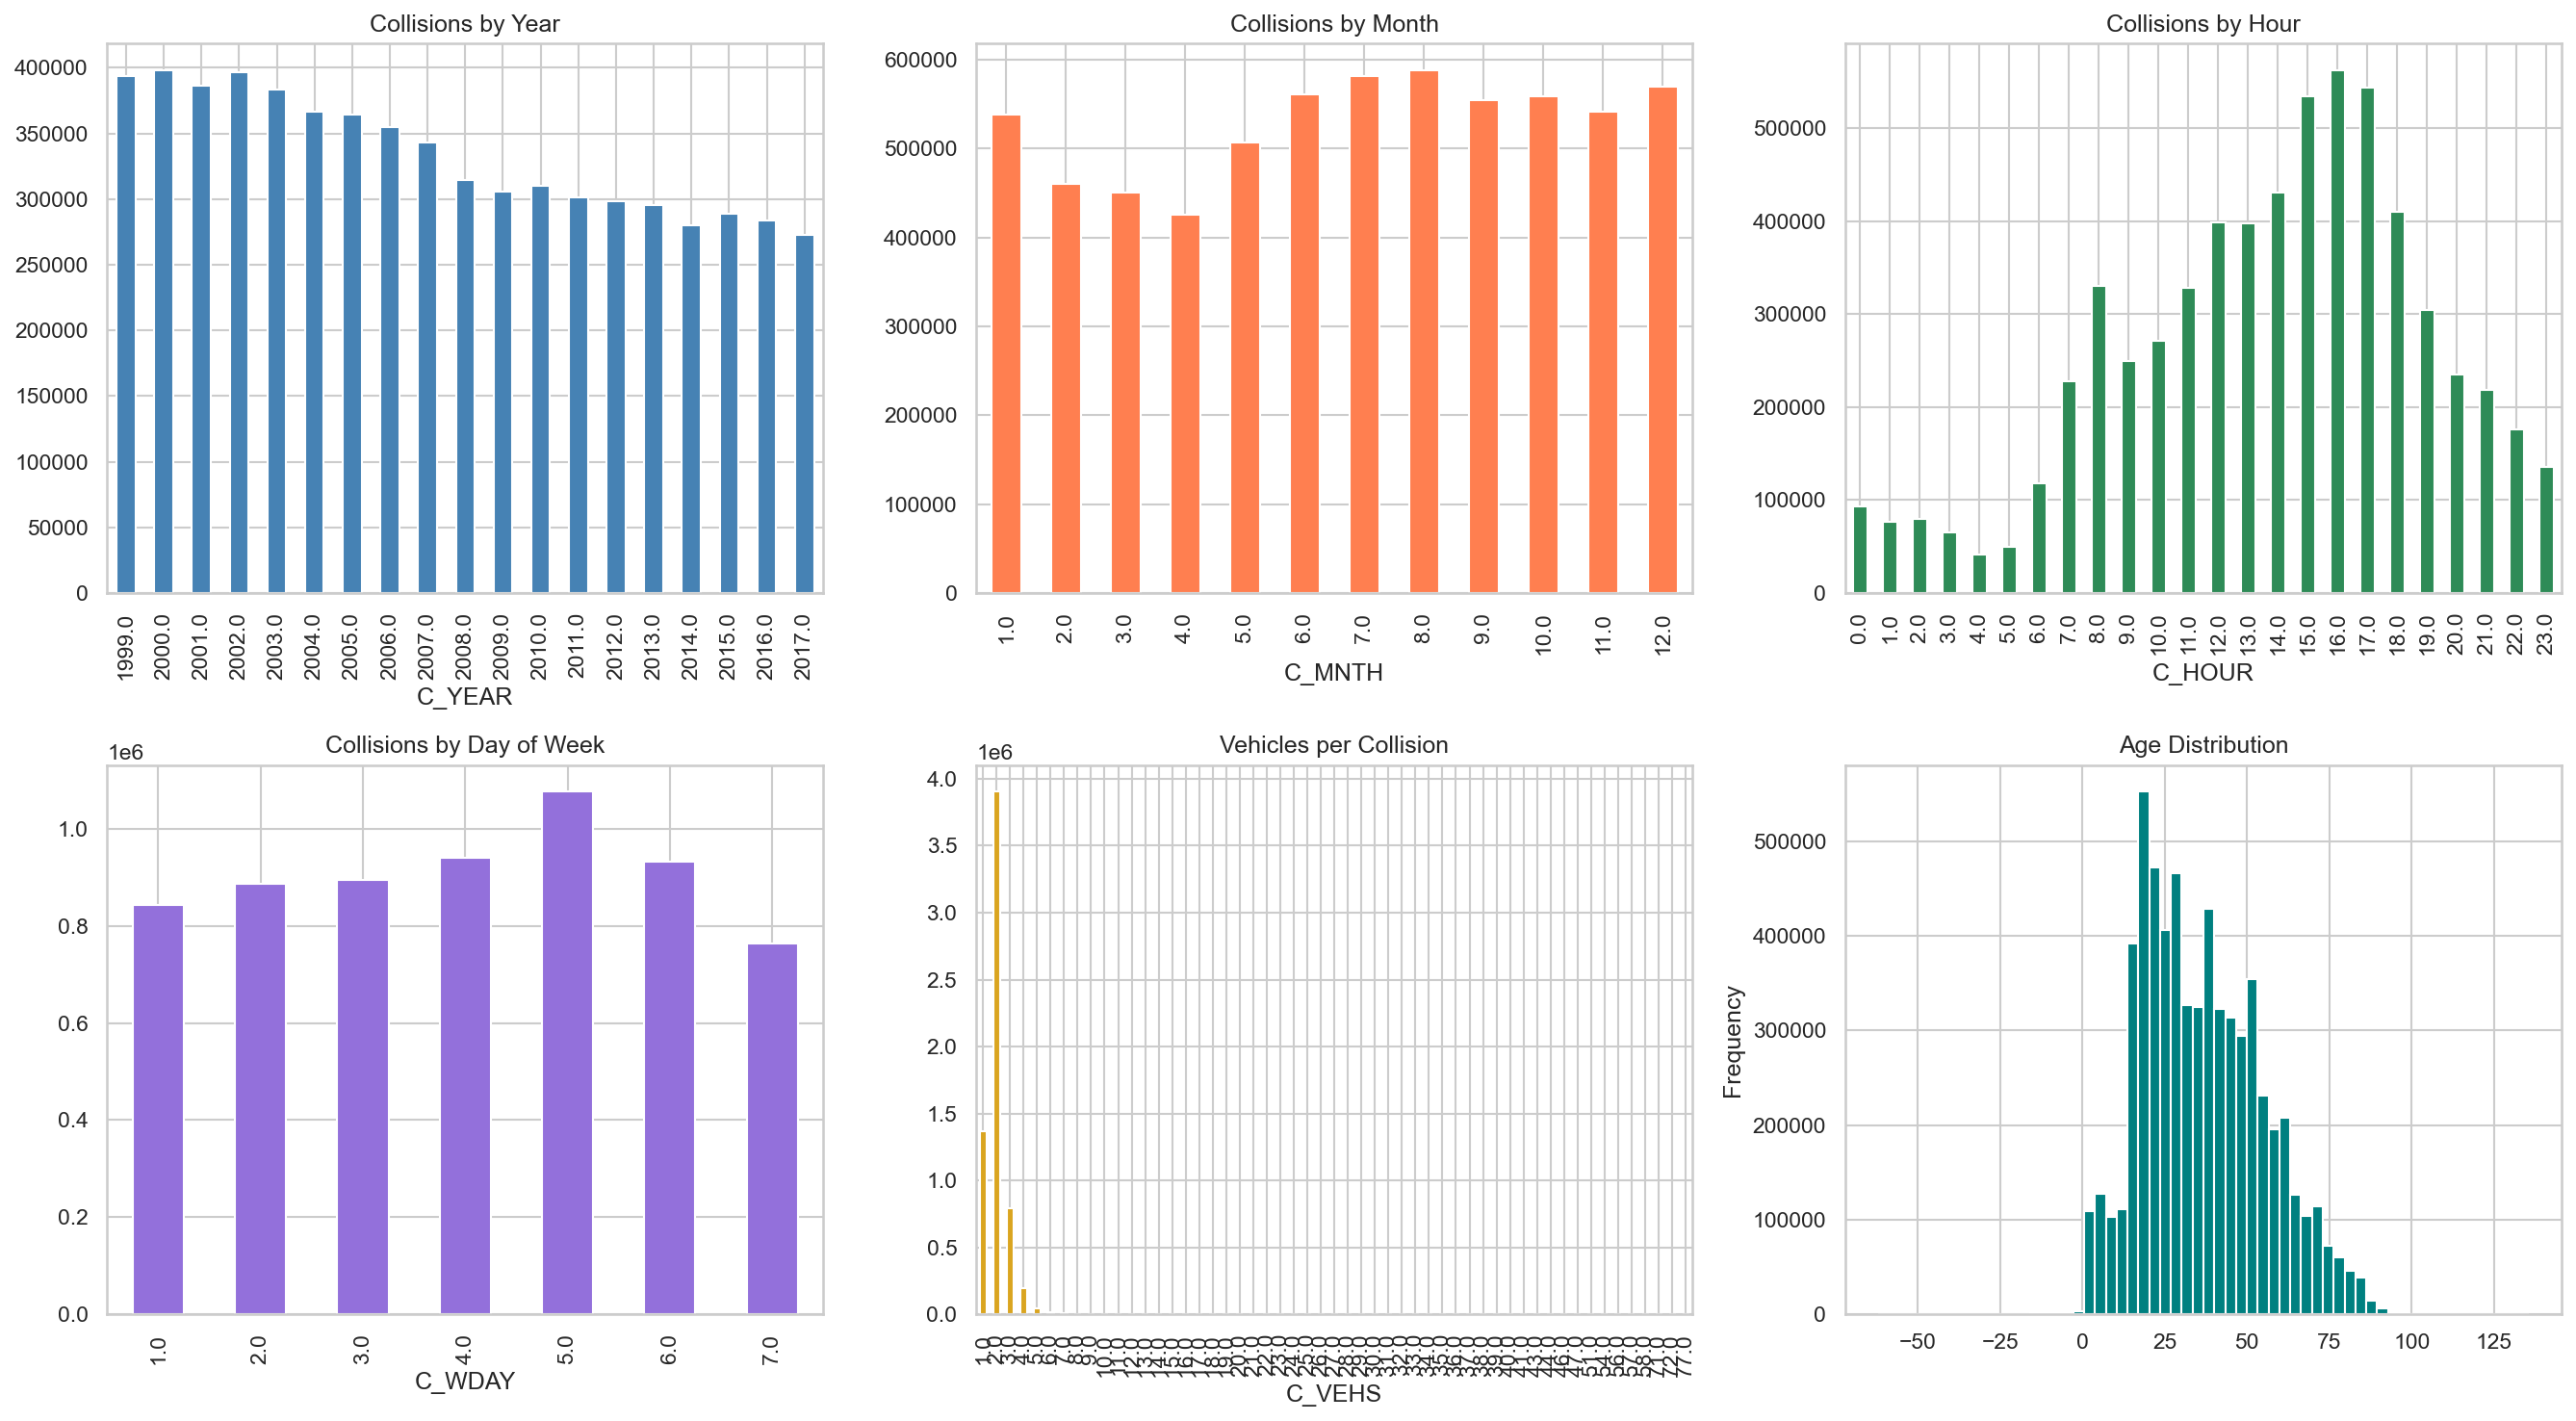

Saved: 01_univariate_analysis.png


In [36]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

data['C_YEAR'].value_counts().sort_index().plot(ax=axes[0,0], kind='bar', color='steelblue')
axes[0,0].set_title('Collisions by Year')
data['C_MNTH'].value_counts().sort_index().plot(ax=axes[0,1], kind='bar', color='coral')
axes[0,1].set_title('Collisions by Month')
data['C_HOUR'].value_counts().sort_index().plot(ax=axes[0,2], kind='bar', color='seagreen')
axes[0,2].set_title('Collisions by Hour')
data['C_WDAY'].value_counts().sort_index().plot(ax=axes[1,0], kind='bar', color='mediumpurple')
axes[1,0].set_title('Collisions by Day of Week')
data['C_VEHS'].value_counts().sort_index().plot(ax=axes[1,1], kind='bar', color='goldenrod')
axes[1,1].set_title('Vehicles per Collision')
data['P_AGE'].plot(ax=axes[1,2], kind='hist', bins=60, color='teal', edgecolor='white')
axes[1,2].set_title('Age Distribution')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '01_univariate_analysis.png'), bbox_inches='tight')
plt.show()
print('Saved: 01_univariate_analysis.png')

### 3.2. Thong ke hai bien (Bivariate Analysis)


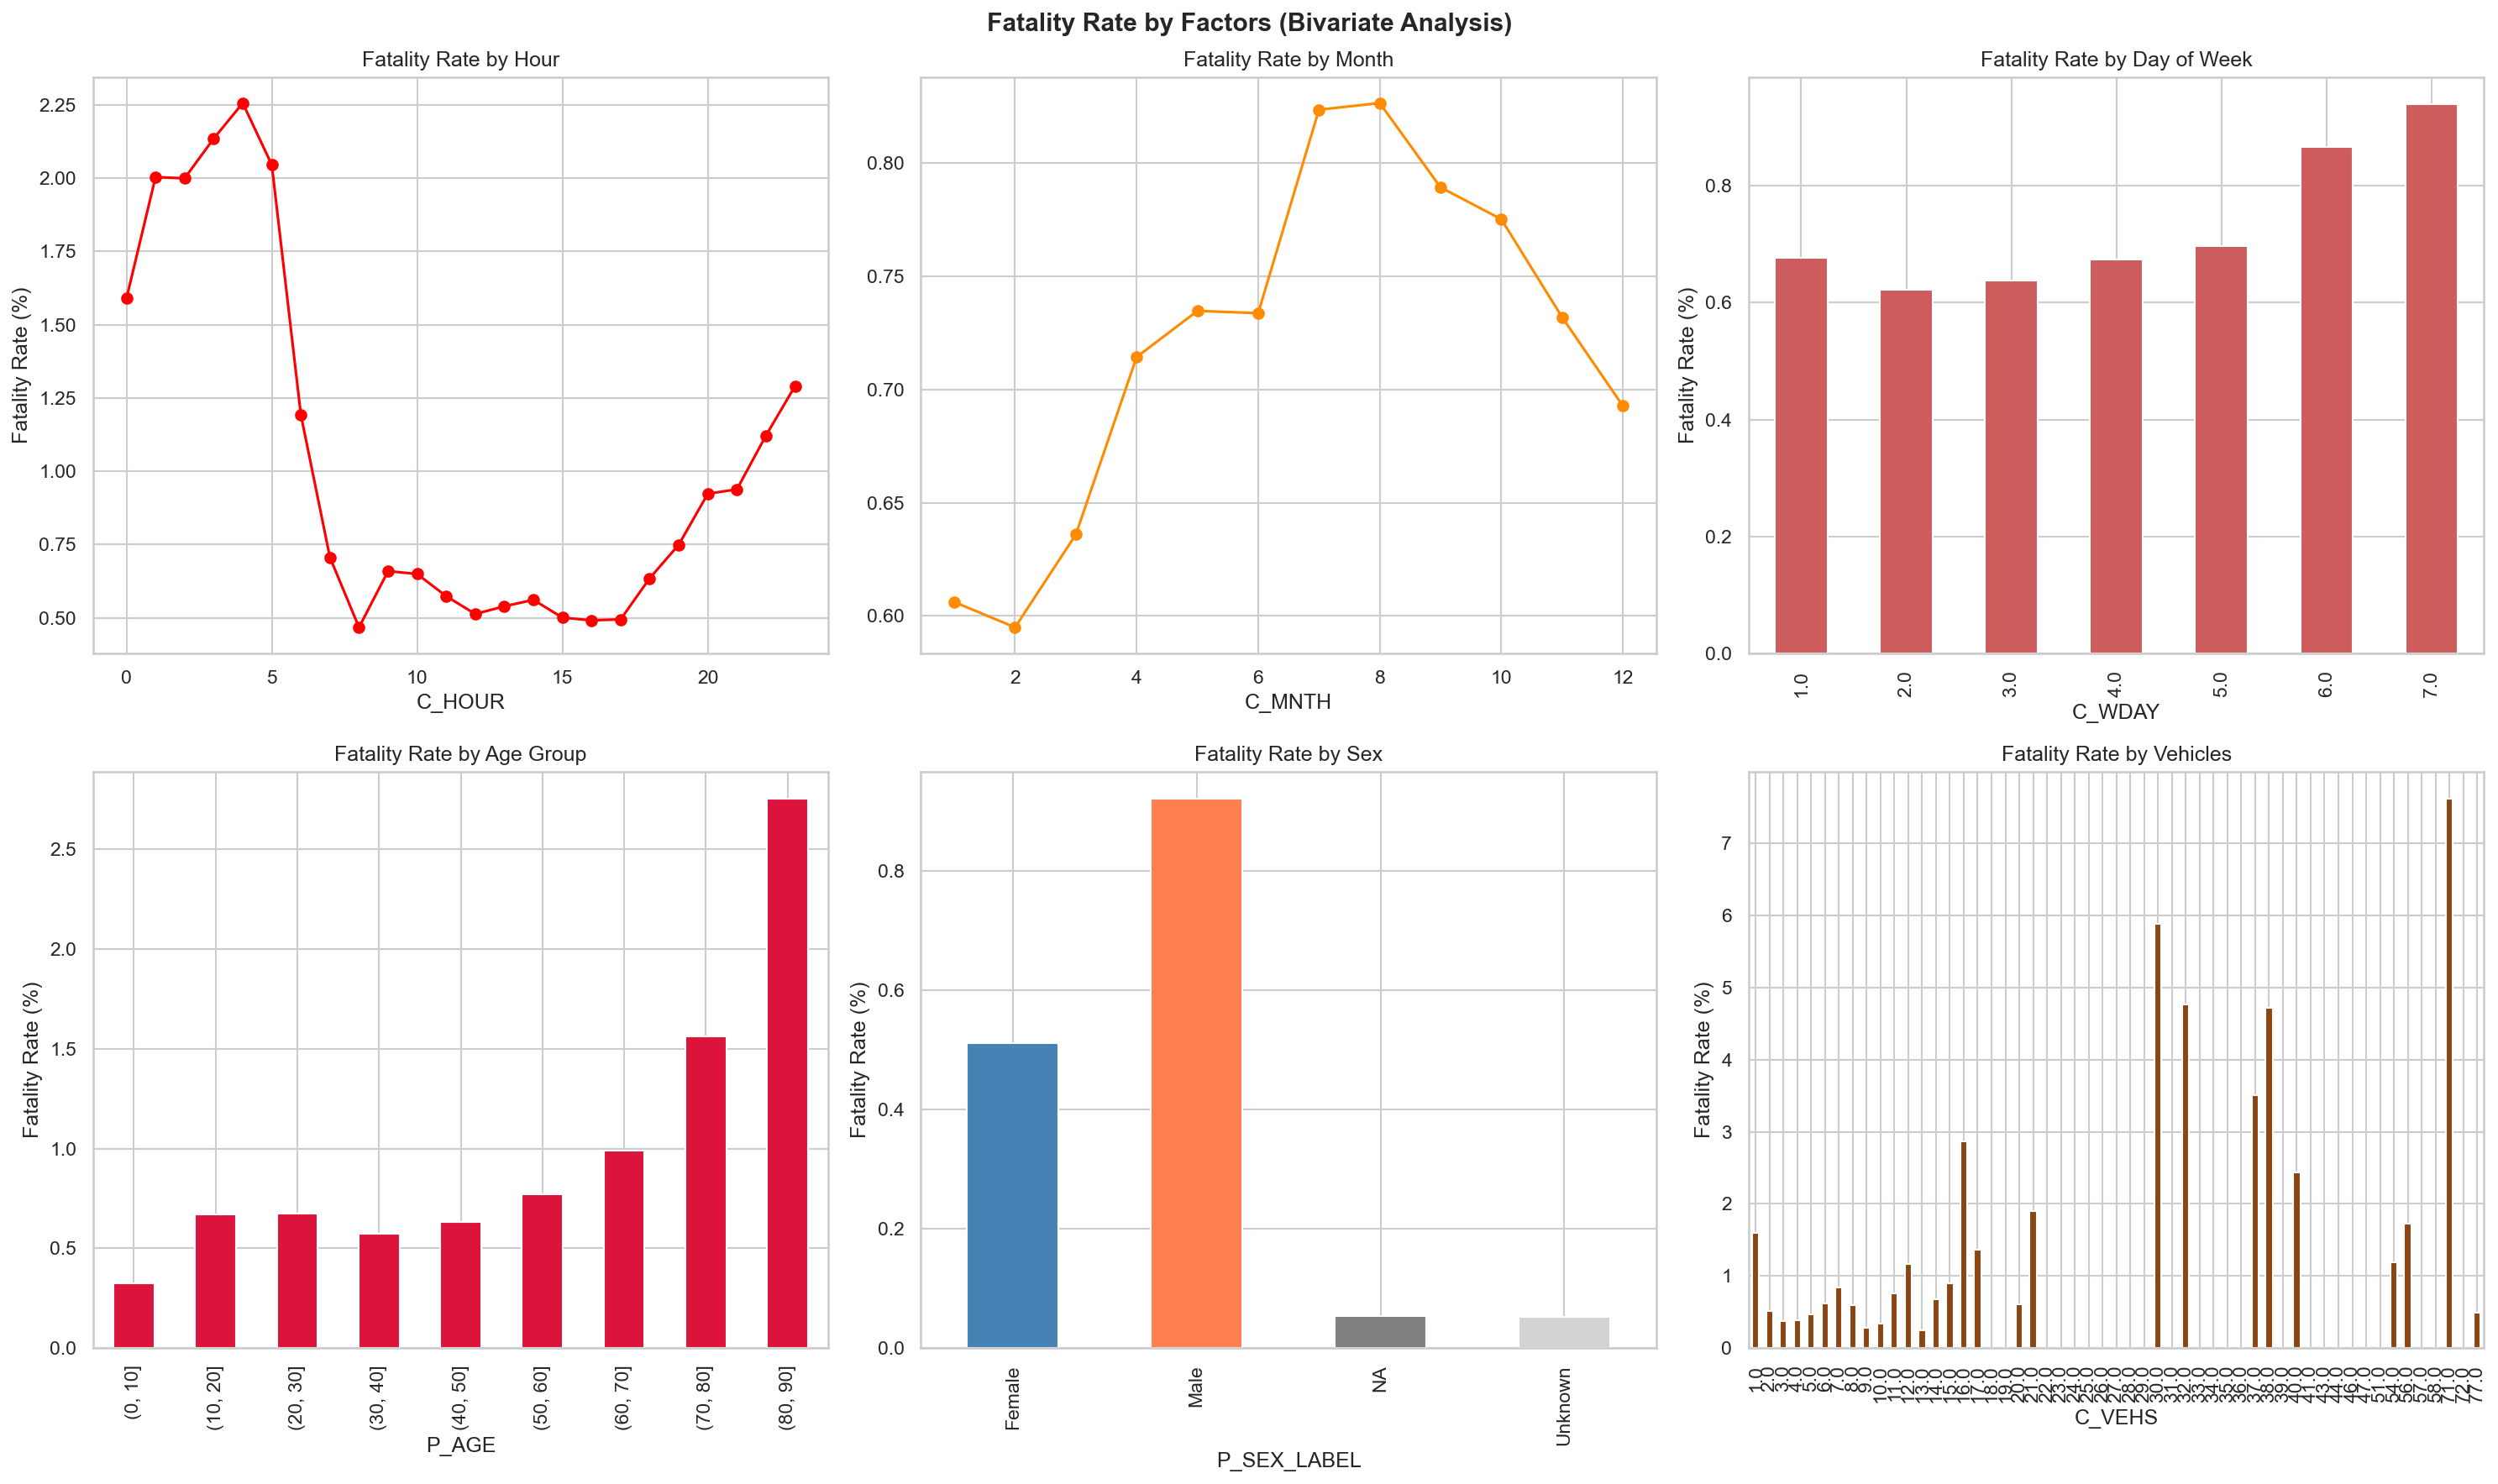

Saved: 02_bivariate_analysis.png


In [37]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

data.groupby('C_HOUR')['Fatality'].mean().mul(100).plot(ax=axes[0,0], marker='o', color='red')
axes[0,0].set_title('Fatality Rate by Hour'); axes[0,0].set_ylabel('Fatality Rate (%)')
data.groupby('C_MNTH')['Fatality'].mean().mul(100).plot(ax=axes[0,1], marker='o', color='darkorange')
axes[0,1].set_title('Fatality Rate by Month')
data.groupby('C_WDAY')['Fatality'].mean().mul(100).plot(ax=axes[0,2], kind='bar', color='indianred')
axes[0,2].set_title('Fatality Rate by Day of Week'); axes[0,2].set_ylabel('Fatality Rate (%)')

age_bins = pd.cut(data['P_AGE'], bins=range(0, 100, 10))
data.groupby(age_bins)['Fatality'].mean().mul(100).plot(ax=axes[1,0], kind='bar', color='crimson')
axes[1,0].set_title('Fatality Rate by Age Group'); axes[1,0].set_ylabel('Fatality Rate (%)')

sex_map = {'M': 'Male', 'F': 'Female', 'U': 'Unknown', 'N': 'NA'}
data['P_SEX_LABEL'] = data['P_SEX'].map(sex_map).fillna('Unknown')
data.groupby('P_SEX_LABEL')['Fatality'].mean().mul(100).plot(ax=axes[1,1], kind='bar',
                                                               color=['steelblue','coral','gray','lightgray'])
axes[1,1].set_title('Fatality Rate by Sex'); axes[1,1].set_ylabel('Fatality Rate (%)')

data.groupby('C_VEHS')['Fatality'].mean().mul(100).plot(ax=axes[1,2], kind='bar', color='saddlebrown')
axes[1,2].set_title('Fatality Rate by Vehicles'); axes[1,2].set_ylabel('Fatality Rate (%)')

plt.suptitle('Fatality Rate by Factors (Bivariate Analysis)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '02_bivariate_analysis.png'), bbox_inches='tight')
plt.show()
print('Saved: 02_bivariate_analysis.png')

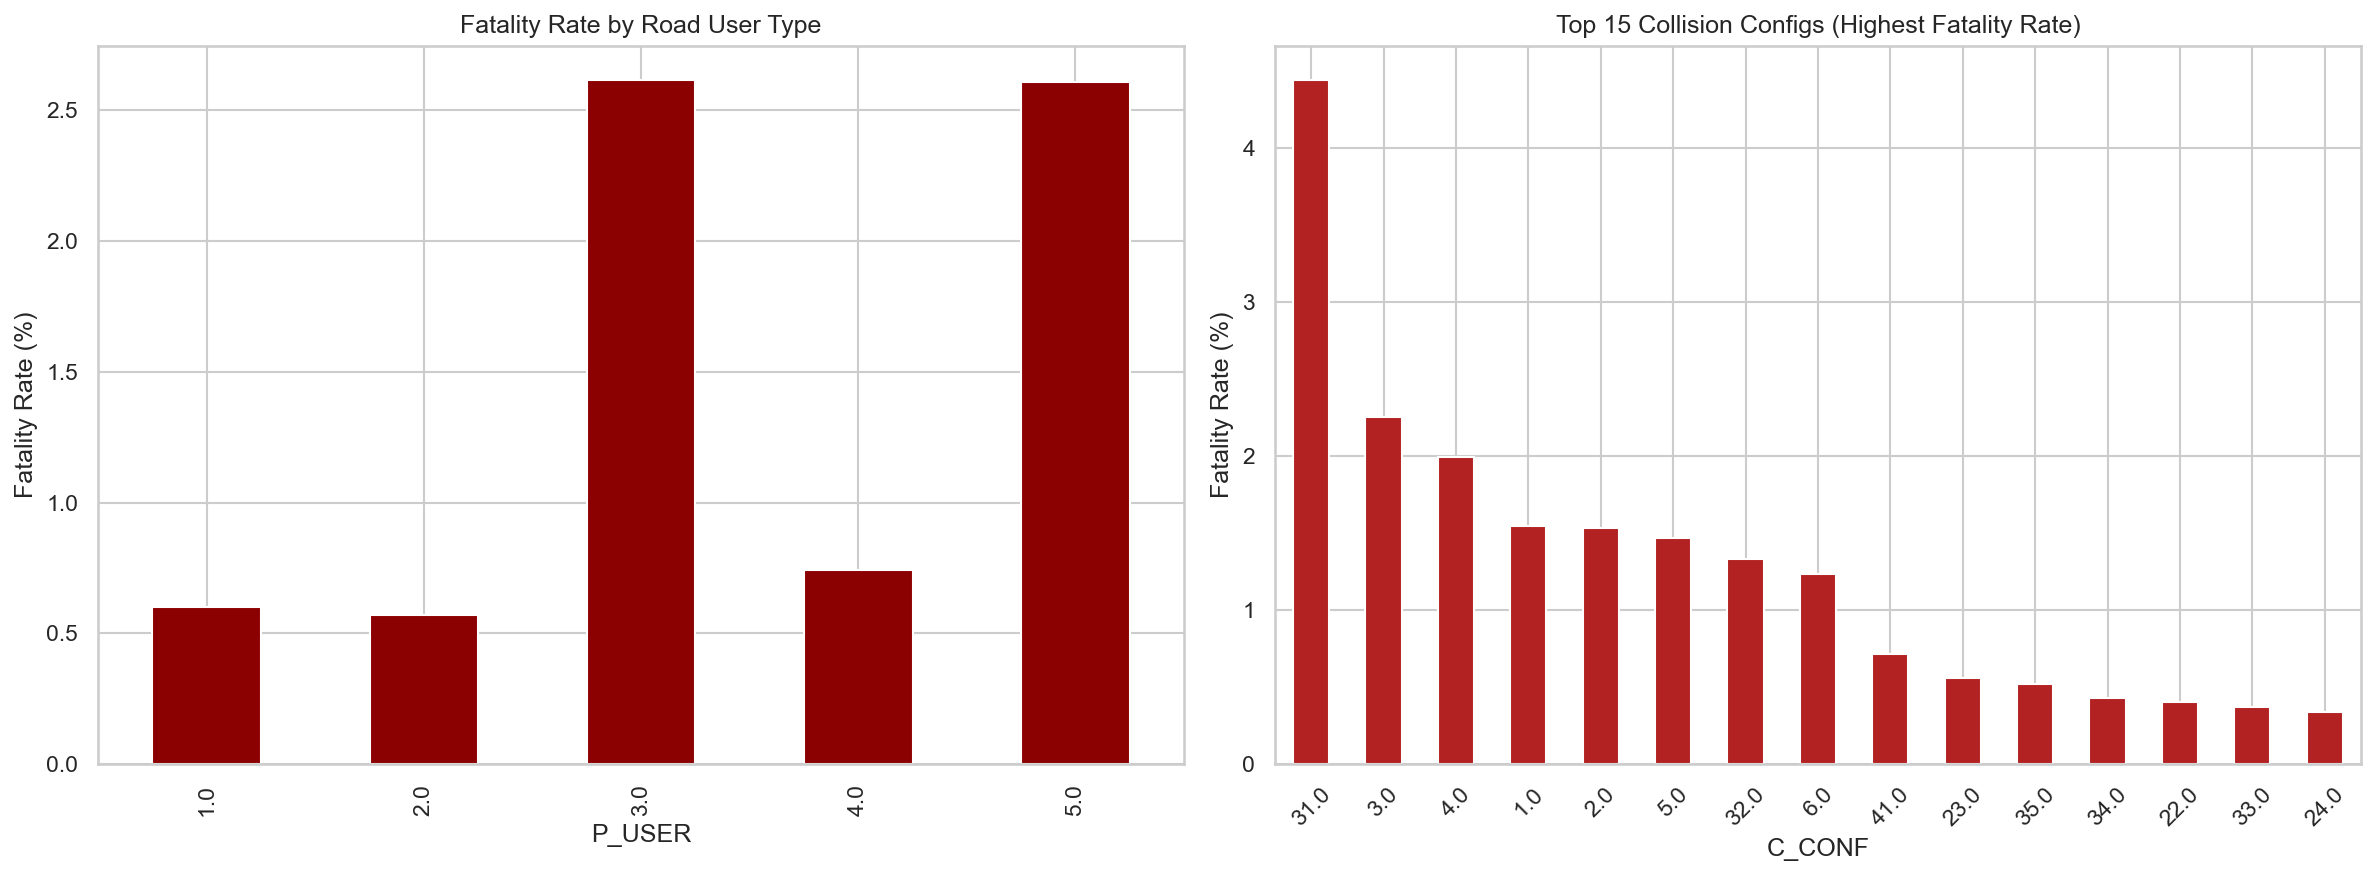

Saved: 03_user_conf_fatality.png


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

data.groupby('P_USER')['Fatality'].mean().mul(100).plot(ax=axes[0], kind='bar', color='darkred')
axes[0].set_title('Fatality Rate by Road User Type'); axes[0].set_ylabel('Fatality Rate (%)')

data.groupby('C_CONF')['Fatality'].mean().sort_values(ascending=False).head(15).mul(100).plot(ax=axes[1], kind='bar', color='firebrick')
axes[1].set_title('Top 15 Collision Configs (Highest Fatality Rate)')
axes[1].set_ylabel('Fatality Rate (%)'); axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '03_user_conf_fatality.png'), bbox_inches='tight')
plt.show()
print('Saved: 03_user_conf_fatality.png')

### 3.3. Phan tich da bien (Multivariate Analysis)


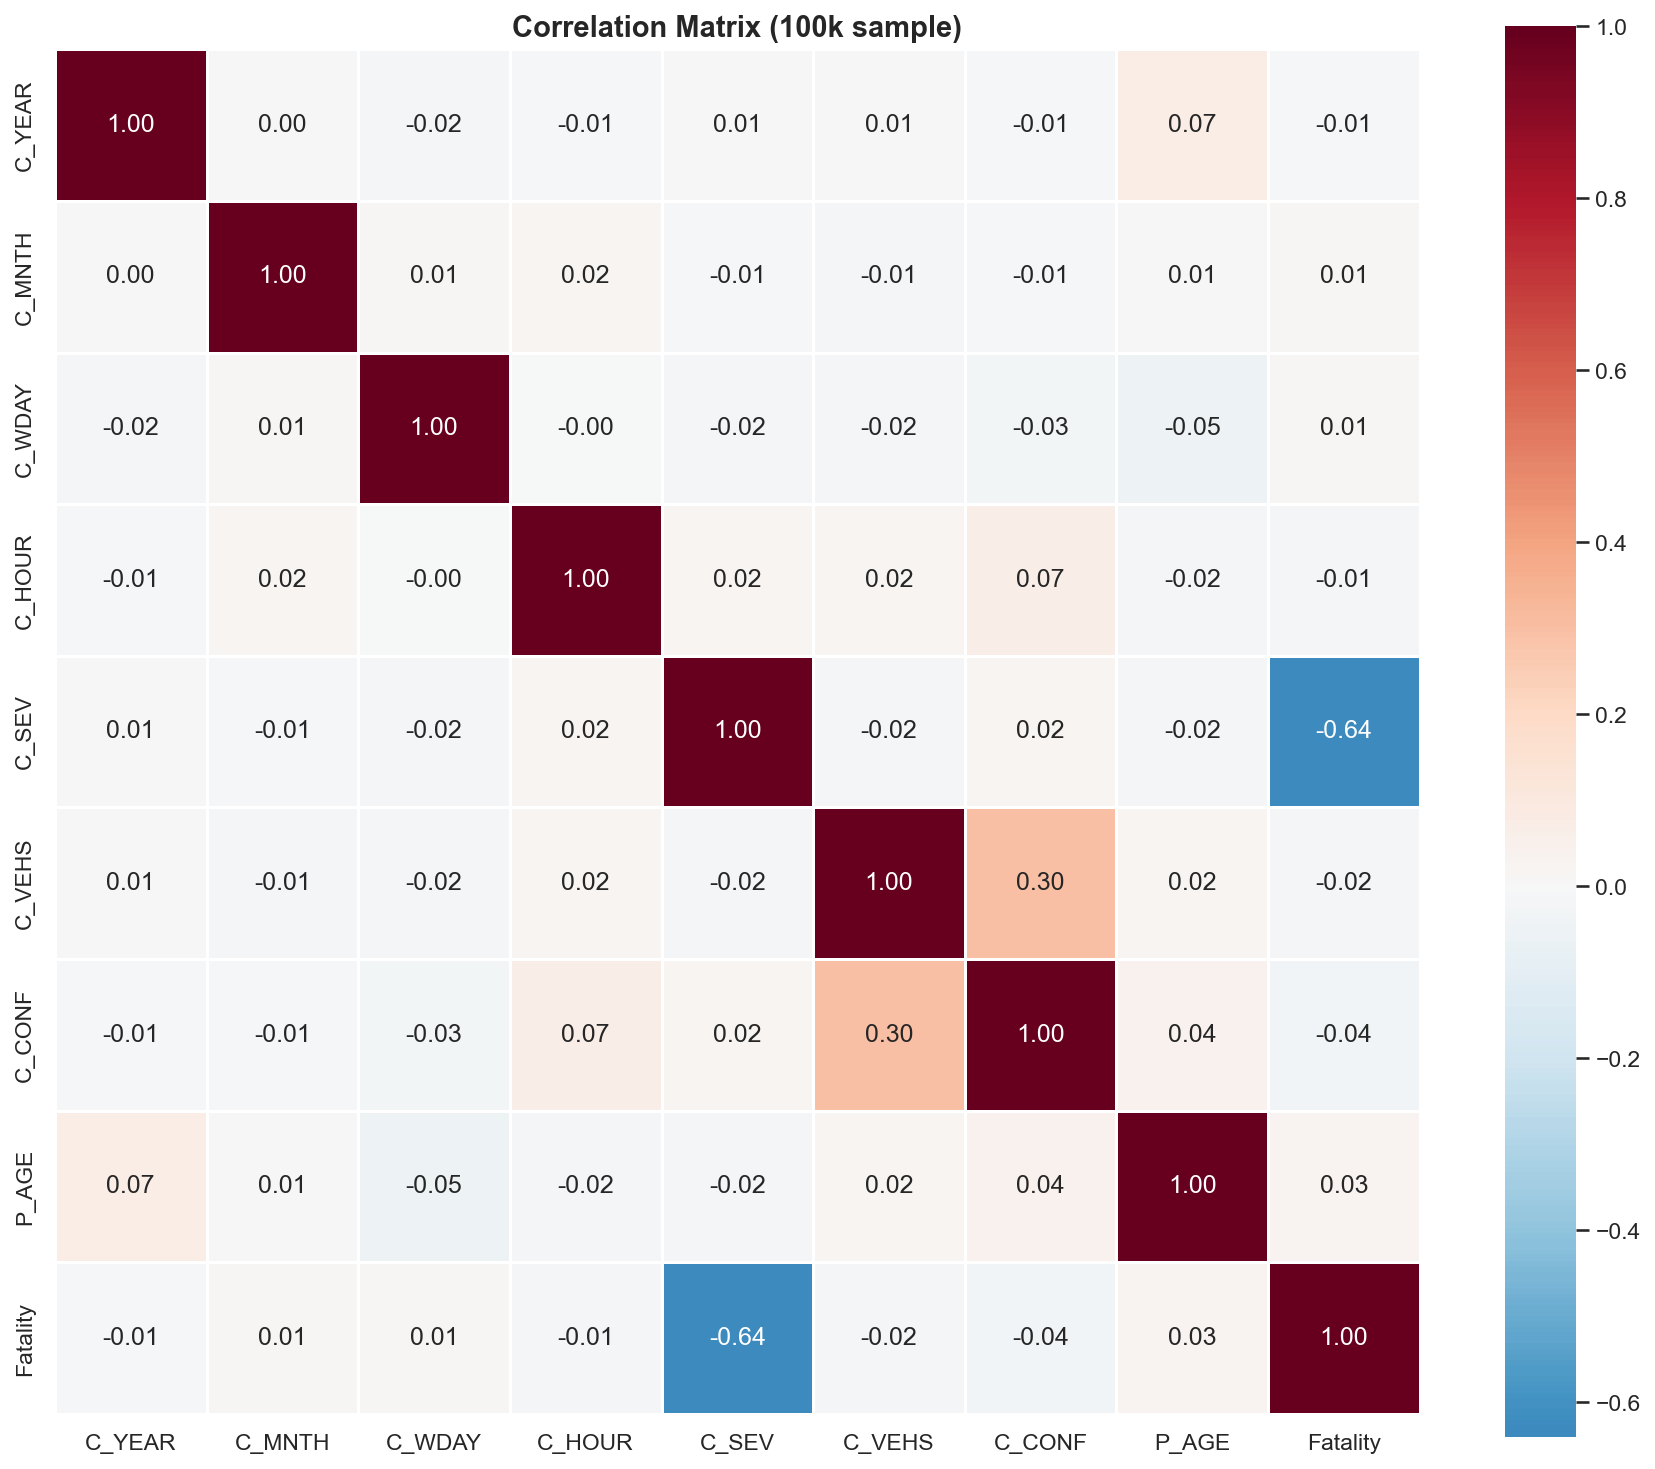

Saved: 03_correlation_matrix.png


In [39]:
corr_cols = ['C_YEAR', 'C_MNTH', 'C_WDAY', 'C_HOUR', 'C_SEV', 'C_VEHS',
             'C_CONF', 'P_AGE', 'Fatality']
corr_sample = data[corr_cols].dropna().sample(n=min(100000, len(data)), random_state=42)
corr_matrix = corr_sample.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix (100k sample)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '03_correlation_matrix.png'), bbox_inches='tight')
plt.show()
print('Saved: 03_correlation_matrix.png')

### 3.4. Khai pha luat ket hop (Apriori Association Rules)


In [40]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

trans_cols = ['Fatality', 'C_CONF', 'C_WTHR', 'C_RSUR', 'C_RCFG', 'C_TRAF', 'C_VEHS', 'P_USER', 'P_SAFE', 'P_PSN', 'V_TYPE']
trans_clean = data[trans_cols].dropna()

# Buoc 1: transaction list
transactions = [
    [f"{col}_{val}" for col, val in zip(trans_cols, row)]
    for row in trans_clean.astype(str).values
]

# Buoc 2: sparse one-hot
te = TransactionEncoder()
onehot_sparse = te.fit(transactions).transform(transactions, sparse=True)
onehot = pd.DataFrame.sparse.from_spmatrix(onehot_sparse, columns=te.columns_)
print(f'One-hot matrix: {onehot.shape}')

# Buoc 3: Apriori
frequent_itemsets = apriori(onehot, min_support=0.01, use_colnames=True, max_len=4, low_memory=True)
print(f'Frequent itemsets: {len(frequent_itemsets)}')

One-hot matrix: (50000, 2282)
Frequent itemsets: 3040


Association rules: 6152


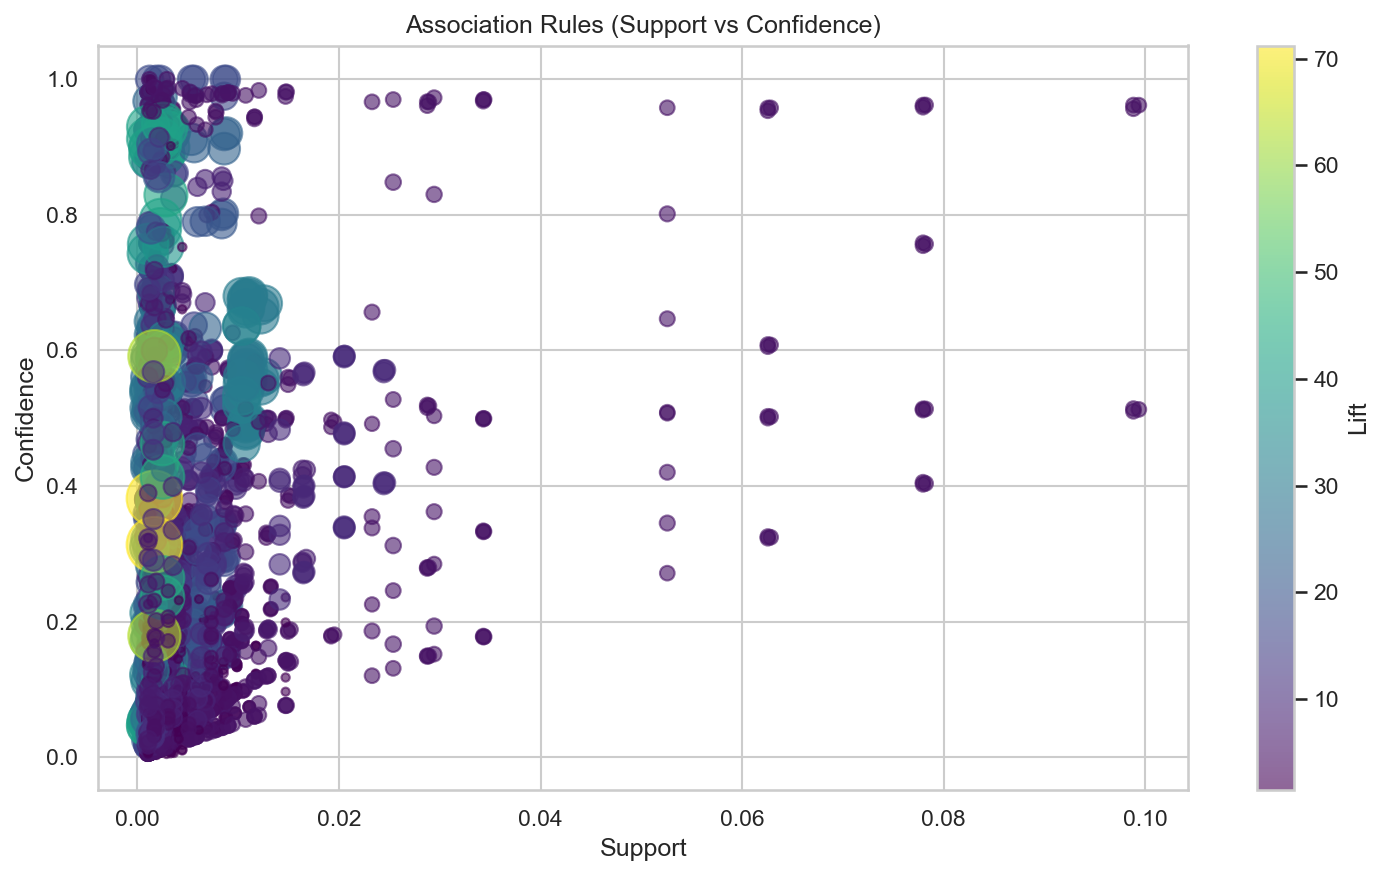

Saved: 04_apriori_rules.png


In [41]:
if len(frequent_itemsets) > 0:
    rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.05)
    print(f'Association rules: {len(rules)}')
    fatal_rules = rules[rules['consequents'].apply(lambda x: 'Fatality_1' in x)]
    fatal_rules = fatal_rules.sort_values('lift', ascending=False).head(15)
    if len(fatal_rules) > 0:
        print('Top 15 rules -> Fatality=1:')
        for _, row in fatal_rules.iterrows():
            ants = ', '.join(sorted(row['antecedents']))
            cons = ', '.join(sorted(row['consequents']))
            print(f'  {{{ants}}} -> {{{cons}}} (sup={row["support"]:.4f}, conf={row["confidence"]:.3f}, lift={row["lift"]:.2f})')
    if len(rules) > 0:
        plt.figure(figsize=(10, 6))
        plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='viridis', alpha=0.6, s=rules['lift']*10)
        plt.colorbar(label='Lift'); plt.xlabel('Support'); plt.ylabel('Confidence')
        plt.title('Association Rules (Support vs Confidence)')
        plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, '04_apriori_rules.png'), bbox_inches='tight'); plt.show()
        print('Saved: 04_apriori_rules.png')
else:
    print('No frequent itemsets found.')

---
## 4. Xay dung Mo hinh Du doan


### 4.1. Chuan bi du lieu cho mo hinh


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from scipy.sparse import hstack, csr_matrix

feature_cols = [
    'C_YEAR', 'C_MNTH', 'C_WDAY', 'C_HOUR', 'C_VEHS',
    'V_TYPE', 'V_YEAR',
    'P_SEX', 'P_AGE', 'P_PSN', 'P_USER'
]
nominal_cols = ['C_CONF', 'C_RCFG', 'C_RALN', 'C_TRAF', 'C_WTHR', 'C_RSUR', 'P_SAFE']
categorical_cols = ['V_TYPE', 'P_SEX']
target = 'Fatality'

sample_size = len(data)
df_model = data[feature_cols + nominal_cols + [target]].copy()
print(f'Model sample: {len(df_model):,}')

gc.collect()
for col in df_model.columns:
    if df_model[col].dtype == 'float64':
        df_model[col] = df_model[col].astype('float32')
    elif df_model[col].dtype == 'int64':
        df_model[col] = df_model[col].astype('int32')

for col in categorical_cols:
    df_model[col] = df_model[col].astype(str)
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

df_model = df_model.dropna().reset_index(drop=True)
print(f'After dropna: {len(df_model):,}')

X_dense = csr_matrix(df_model[feature_cols].values)

ohe = OneHotEncoder(sparse_output=True, min_frequency=0.001,
                     handle_unknown='infrequent_if_exist')
X_ohe = ohe.fit_transform(df_model[nominal_cols])

all_feature_names = feature_cols + list(ohe.get_feature_names_out())
print(f'One-hot encoding: {len(all_feature_names)} features')

X = hstack([X_dense, X_ohe], format='csr')
y = df_model[target].astype(int).values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Train fatality rate: {y_train.mean()*100:.3f}%')

Model sample: 200,000
One-hot encoding: 67 features (from 17 original)
After dropna: 197,108
Train: 137,975 | Test: 59,133
Train fatality rate: 0.713%


### 4.2. Xu ly mat can bang lop (Class Imbalance)


In [43]:
from imblearn.under_sampling import RandomUnderSampler

# Native ROSE implementation: Gaussian kernel smoothed bootstrap
class ROSE:
    def __init__(self, sampling_strategy='auto', random_state=42, k=5):
        self.sampling_strategy = sampling_strategy
        self.random_state = random_state
        self.k = k

    def fit_resample(self, X, y):
        X, y = np.asarray(X), np.asarray(y)
        rng = np.random.RandomState(self.random_state)
        classes, counts = np.unique(y, return_counts=True)
        minority_class = classes[np.argmin(counts)]
        majority_class = classes[np.argmax(counts)]
        X_min = X[y == minority_class]
        n_min = X_min.shape[0]
        n_maj = X[y == majority_class].shape[0]
        if self.sampling_strategy == 'auto':
            n_synth = n_maj - n_min
        elif isinstance(self.sampling_strategy, float):
            if self.sampling_strategy < 1:
                n_desired_min = int(n_maj * self.sampling_strategy)
            else:
                n_desired_min = int(n_min * self.sampling_strategy)
            n_synth = max(0, n_desired_min - n_min)
        else:
            n_synth = n_maj - n_min
        if n_synth <= 0:
            return X, y
        from sklearn.neighbors import NearestNeighbors
        nn = NearestNeighbors(n_neighbors=min(self.k + 1, n_min))
        nn.fit(X_min)
        distances, _ = nn.kneighbors(X_min)
        h_sq = np.mean(distances[:, 1:] ** 2)
        synth_samples = []
        for _ in range(n_synth):
            idx = rng.randint(n_min)
            xi = X_min[idx]
            synth = xi + rng.normal(0, np.sqrt(h_sq + 1e-10), size=xi.shape)
            synth = np.where(synth > 0.5, 1.0, 0.0)
            synth_samples.append(synth)
        X_synth = np.array(synth_samples)
        y_synth = np.full(n_synth, minority_class)
        X_res = np.vstack([X, X_synth])
        y_res = np.hstack([y, y_synth])
        return X_res, y_res

rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)
print(f'Undersampling: {X_train_under.shape[0]:,} (fatal={sum(y_train_under==1):,})')

rose = ROSE(sampling_strategy=0.5, random_state=42)
X_train_rose, y_train_rose = rose.fit_resample(X_train, y_train)
print(f'ROSE: {X_train_rose.shape[0]:,} (fatal={sum(y_train_rose==1):,})')

# Mixed: undersampling + ROSE (combined-sampling)
rus2 = RandomUnderSampler(random_state=42, sampling_strategy=0.4)
X_train_mix, y_train_mix = rus2.fit_resample(X_train, y_train)
rose2 = ROSE(sampling_strategy=0.8, random_state=42)
X_train_mix, y_train_mix = rose2.fit_resample(X_train_mix, y_train_mix)
print(f'Mixed: {X_train_mix.shape[0]:,} (fatal={sum(y_train_mix==1):,})')

Undersampling: 1,968 (fatal=984)
ROSE: 138,467 (fatal=1,476)
Mixed: 4,231 (fatal=1,771)


### 4.3. Mo hinh 1: Lasso Regression


In [44]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f'\n{"="*45}')
    print(f'{name}')
    print(f'{"="*45}')
    print(f'  Accuracy:    {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Sensitivity: {sensitivity:.4f} ({sensitivity*100:.2f}%)')
    print(f'  Specificity: {specificity:.4f} ({specificity*100:.2f}%)')
    print(f'  CM: [[{tn} {fp}] [{fn} {tp}]]')
    return acc, sensitivity, specificity

In [45]:
results = []

sampling_data = [
    ('No Sampling', X_train, y_train),
    ('Undersampling', X_train_under, y_train_under),
    ('ROSE', X_train_rose, y_train_rose),
    ('Mixed Sampling', X_train_mix, y_train_mix),
]

print('--- Lasso Regression (L1, 5-fold Cross-Validated) ---')
for sname, X_tr, y_tr in sampling_data:
    lasso = LogisticRegressionCV(penalty='l1', solver='saga', Cs=10, cv=5,
                                 max_iter=1000,
                                 random_state=42, n_jobs=-1)
    lasso.fit(X_tr, y_tr)
    acc, sens, spec = evaluate_model(f'Lasso + {sname}', lasso, X_test, y_test)
    results.append({'Model': f'Lasso + {sname}', 'Accuracy': acc, 'Sensitivity': sens, 'Specificity': spec})

--- Lasso Regression (L1, 5-fold Cross-Validated) ---

Lasso + No Sampling
  Accuracy:    0.7921 (79.21%)
  Sensitivity: 0.7275 (72.75%)
  Specificity: 0.7925 (79.25%)
  CM: [[46530 12181] [115 307]]

Lasso + Undersampling
  Accuracy:    0.7416 (74.16%)
  Sensitivity: 0.6564 (65.64%)
  Specificity: 0.7422 (74.22%)
  CM: [[43577 15134] [145 277]]

Lasso + ROSE
  Accuracy:    0.9929 (99.29%)
  Sensitivity: 0.0000 (0.00%)
  Specificity: 1.0000 (100.00%)
  CM: [[58711 0] [422 0]]

Lasso + Mixed Sampling
  Accuracy:    0.9324 (93.24%)
  Sensitivity: 0.3389 (33.89%)
  Specificity: 0.9366 (93.66%)
  CM: [[54991 3720] [279 143]]


### 4.4. Mo hinh 2: XGBoost


In [46]:
from xgboost import XGBClassifier

print('\n--- XGBoost Classifier ---')
best_xgb = None
for sname, X_tr, y_tr in sampling_data:
    if sname == 'No Sampling':
        spw = 1
    else:
        neg = sum(y_tr == 0)
        pos = sum(y_tr == 1)
        spw = neg / pos if pos > 0 else 1
    xgb = XGBClassifier(n_estimators=1200, learning_rate=0.5, max_depth=3,
                         subsample=0.8, colsample_bytree=0.8,
                         scale_pos_weight=spw,
                         random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
    xgb.fit(X_tr, y_tr)
    acc, sens, spec = evaluate_model(f'XGBoost + {sname}', xgb, X_test, y_test)
    results.append({'Model': f'XGBoost + {sname}', 'Accuracy': acc, 'Sensitivity': sens, 'Specificity': spec})
    if sname == 'Mixed Sampling':
        best_xgb = xgb


--- XGBoost Classifier ---

XGBoost + No Sampling
  Accuracy:    0.9632 (96.32%)
  Sensitivity: 0.2488 (24.88%)
  Specificity: 0.9684 (96.84%)
  CM: [[56853 1858] [317 105]]

XGBoost + Undersampling
  Accuracy:    0.7439 (74.39%)
  Sensitivity: 0.7417 (74.17%)
  Specificity: 0.7439 (74.39%)
  CM: [[43675 15036] [109 313]]

XGBoost + ROSE
  Accuracy:    0.9692 (96.92%)
  Sensitivity: 0.2370 (23.70%)
  Specificity: 0.9744 (97.44%)
  CM: [[57209 1502] [322 100]]

XGBoost + Mixed Sampling
  Accuracy:    0.8626 (86.26%)
  Sensitivity: 0.5829 (58.29%)
  Specificity: 0.8646 (86.46%)
  CM: [[50762 7949] [176 246]]


### 4.5. So sanh ket qua cac mo hinh


In [47]:
results_df = pd.DataFrame(results)
results_df['Accuracy(%)'] = results_df['Accuracy'] * 100
results_df['Sensitivity(%)'] = results_df['Sensitivity'] * 100
results_df['Specificity(%)'] = results_df['Specificity'] * 100
print('MODEL COMPARISON')
print(results_df[['Model', 'Accuracy(%)', 'Sensitivity(%)', 'Specificity(%)']].to_string(index=False))
results_df.to_csv(os.path.join(OUT_DIR, 'model_results.csv'), index=False)

MODEL COMPARISON
                   Model  Accuracy(%)  Sensitivity(%)  Specificity(%)
     Lasso + No Sampling    79.206196       72.748815       79.252610
   Lasso + Undersampling    74.161636       65.639810       74.222888
            Lasso + ROSE    99.286354        0.000000      100.000000
  Lasso + Mixed Sampling    93.237279       33.886256       93.663879
   XGBoost + No Sampling    96.321851       24.881517       96.835346
 XGBoost + Undersampling    74.388243       74.170616       74.389808
          XGBoost + ROSE    96.915428       23.696682       97.441706
XGBoost + Mixed Sampling    86.259787       58.293839       86.460800


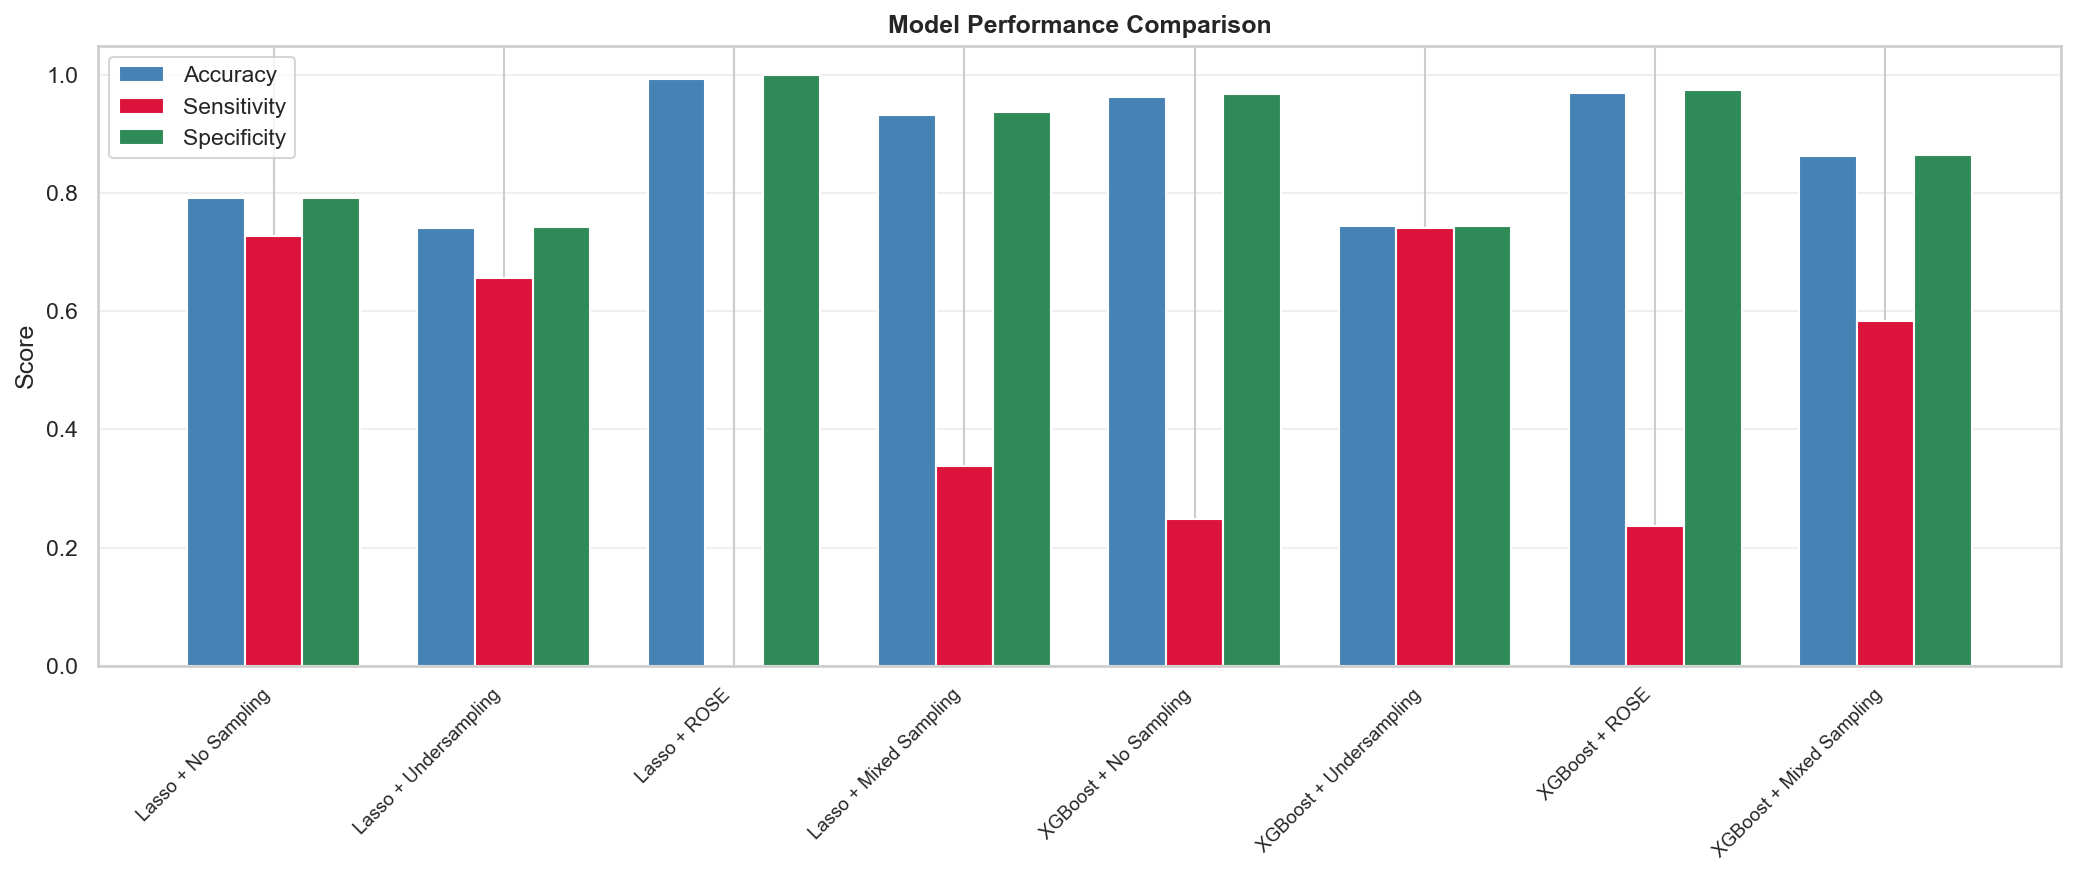

Saved: 05_model_comparison.png


In [48]:
fig, ax = plt.subplots(figsize=(14, 6))
x_vals = np.arange(len(results_df))
width = 0.25
ax.bar(x_vals - width, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x_vals, results_df['Sensitivity'], width, label='Sensitivity', color='crimson')
ax.bar(x_vals + width, results_df['Specificity'], width, label='Specificity', color='seagreen')
ax.set_xticks(x_vals)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, '05_model_comparison.png'), bbox_inches='tight')
plt.show()
print('Saved: 05_model_comparison.png')

---
## 5. Feature Importance (Tam quan trong cua cac yeu to)


Top features (XGBoost + Mixed Sampling, aggregated):
   1. C_CONF      0.3024
   2. C_TRAF      0.1435
   3. P_SAFE      0.0958
   4. C_RALN      0.0894
   5. C_RCFG      0.0856
   6. C_RSUR      0.0757
   7. C_WTHR      0.0683
   8. P_USER      0.0297
   9. C_VEHS      0.0153
  10. V_TYPE      0.0152


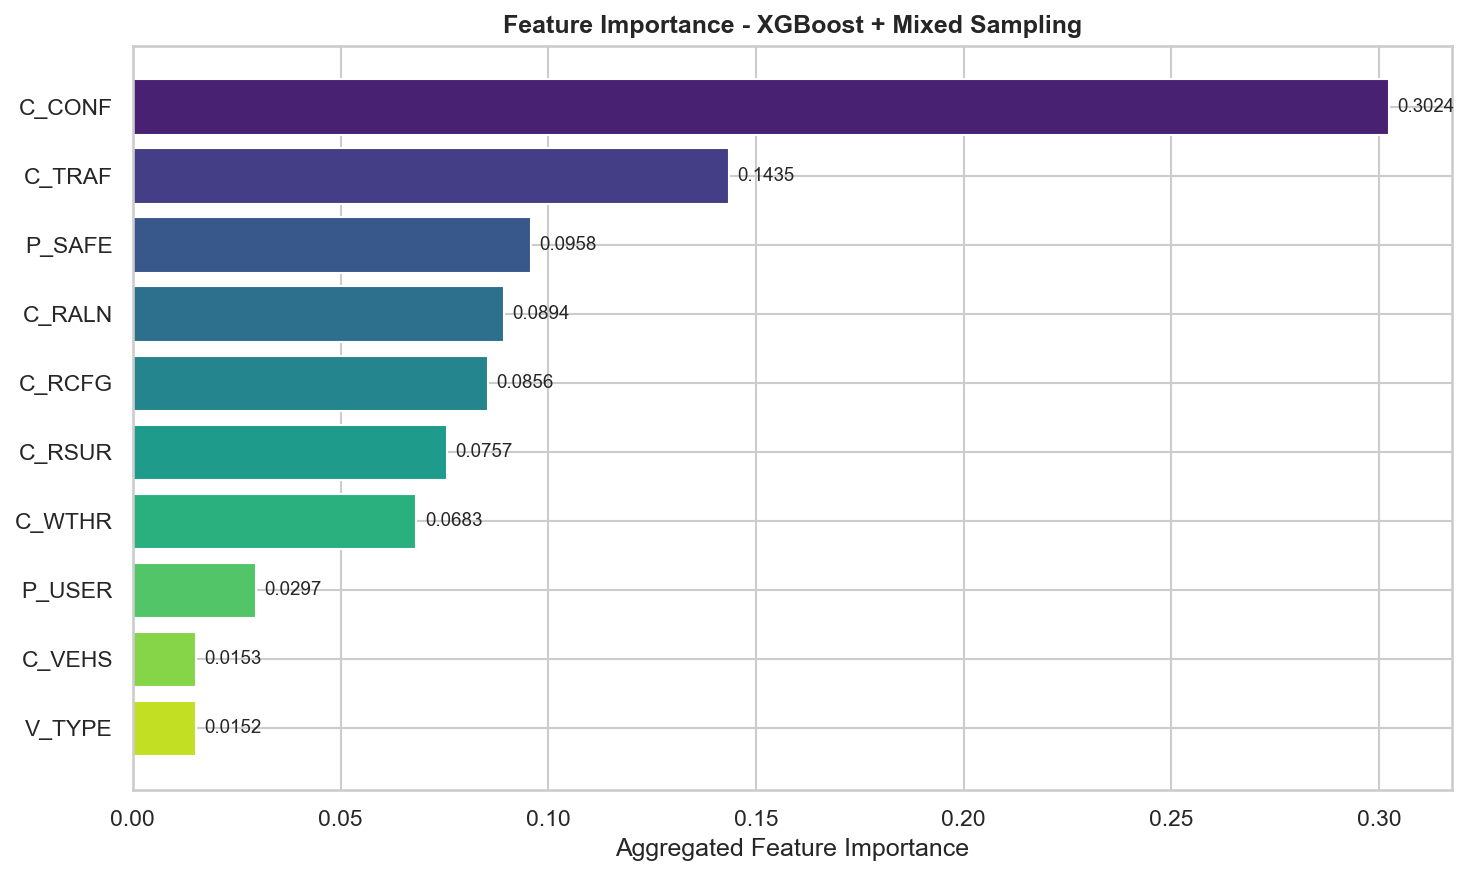

Saved: 06_feature_importance.png


In [49]:
if best_xgb is not None:
    raw_importance = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': best_xgb.feature_importances_
    })
    def base_feature_name(f):
        for prefix in nominal_cols + ['V_TYPE', 'P_SEX', 'P_SAFE']:
            if f.startswith(prefix + '_'):
                return prefix
        return f
    raw_importance['BaseFeature'] = raw_importance['Feature'].apply(base_feature_name)
    importance_df = raw_importance.groupby('BaseFeature')['Importance'].sum().reset_index()
    importance_df = importance_df.sort_values('Importance', ascending=False)
    print('Top features (XGBoost + Mixed Sampling, aggregated):')
    for i, (_, row) in enumerate(importance_df.head(10).iterrows(), 1):
        print(f'  {i:2d}. {row["BaseFeature"]:10s}  {row["Importance"]:.4f}')
    fig, ax = plt.subplots(figsize=(10, 6))
    top10 = importance_df.head(10)
    colors = sns.color_palette('viridis', n_colors=len(top10))
    ax.barh(range(len(top10)), top10['Importance'][::-1], color=colors[::-1])
    ax.set_yticks(range(len(top10))); ax.set_yticklabels(top10['BaseFeature'][::-1])
    ax.set_xlabel('Aggregated Feature Importance')
    ax.set_title('Feature Importance - XGBoost + Mixed Sampling', fontweight='bold')
    for i, v in enumerate(top10['Importance'][::-1]):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, '06_feature_importance.png'), bbox_inches='tight')
    plt.show()
    print('Saved: 06_feature_importance.png')
    importance_df.to_csv(os.path.join(OUT_DIR, 'feature_importance.csv'), index=False)

---
## 6. Danh gia va Ket luan


In [50]:
print('=' * 70)
print('PIPELINE COMPLETE')
print('=' * 70)
print(f'''
KEY FINDINGS:
1. Dataset: {n_collisions:,} collisions, {len(data):,} records (1999-2017)
2. Fatality rate: {data["Fatality"].mean()*100:.3f}%
3. Best model: XGBoost + Mixed Sampling
4. Top features: See feature_importance.csv

All outputs saved to: {os.path.abspath(OUT_DIR)}/
''')

summary = {
    'dataset': 'Canada NCDB (1999-2017)',
    'total_collisions': int(n_collisions),
    'total_records': int(len(data)),
    'fatality_rate_pct': round(float(data['Fatality'].mean() * 100), 3),
}
with open(os.path.join(OUT_DIR, 'pipeline_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2, default=str, ensure_ascii=False)
print('Saved: pipeline_summary.json')

PIPELINE COMPLETE

KEY FINDINGS:
1. Dataset: 2,570,302 collisions, 6,337,651 records (1999-2017)
2. Fatality rate: 0.726%
3. Best model: XGBoost + Mixed Sampling
4. Top features: See feature_importance.csv

All outputs saved to: c:\Users\ADMIN\Desktop\TT\B2205935-LeNgocDuc-TranThanhPhuc-tuan-02\code\outputs\canada_pipeline/

Saved: pipeline_summary.json
